In [2]:
from pathlib import Path
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# DATASET 3
# =========================

DATASET_ID = 3

BASE_DIR_3 = Path(".")   # IMPORTANT : on est déjà dans dataset3

FEATURES_PKL_3 = BASE_DIR_3 / "pdfFeatures3.pkl"
TIMESERIES_PKL_3 = BASE_DIR_3 / "pdfTimeSeries3.pkl"

print("Dossier courant :", Path.cwd())
print("Features 3 :", FEATURES_PKL_3)
print("TimeSeries 3 :", TIMESERIES_PKL_3)


Dossier courant : c:\Users\user\Documents\ST4\dataset3
Features 3 : pdfFeatures3.pkl
TimeSeries 3 : pdfTimeSeries3.pkl


In [3]:
# =========================
# CHARGEMENT TIMESERIES 3
# =========================

with open(TIMESERIES_PKL_3, "rb") as f:
    pdfTimeSeries_3 = pickle.load(f)

print("pdfTimeSeries 3 chargées")
print(type(pdfTimeSeries_3))

pdfTimeSeries 3 chargées
<class 'pandas.core.frame.DataFrame'>


C:\Users\user\AppData\Local\Temp\ipykernel_6312\3817167356.py:6: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  pdfTimeSeries_3 = pickle.load(f)


In [4]:
# =========================
# CHARGEMENT FEATURES 3
# =========================

with open(FEATURES_PKL_3, "rb") as f:
    features_3 = pickle.load(f)

print("Features 3 chargées")
print(type(features_3))

Features 3 chargées
<class 'pandas.core.frame.DataFrame'>


In [5]:
# Compter les identifiants disponibles
identifiants_3 = pdfTimeSeries_3["i"].unique()

print("Nombre d'identifiants :", len(identifiants_3))
print("Quelques identifiants :", identifiants_3[:10])

# Choisir le premier identifiant
identifiant_3 = identifiants_3[0]

print("Identifiant choisi :", identifiant_3)

Nombre d'identifiants : 160
Quelques identifiants : ['5YPTSOKST' 'B7G3FNKC6' 'TGAX50T37' '2M7T1FWOA' '9CDUOBC8E' 'U9VQ3PBNV'
 '9CMDS4Y0R' 'BNDEAV78K' 'SSCEZBFGG' 'URLHXH7H4']
Identifiant choisi : 5YPTSOKST


In [6]:
# Filtrer la time series de cet identifiant
df_ts_3 = pdfTimeSeries_3[pdfTimeSeries_3["i"] == identifiant_3].copy()

display(df_ts_3.head())
print("Nombre de points :", len(df_ts_3))

,u,y,i,e
0,0.0,-0.012316,5YPTSOKST,-0.012316
1,0.0,-0.003539,5YPTSOKST,-0.003539
2,0.0,0.026586,5YPTSOKST,0.026586
3,0.0,0.055004,5YPTSOKST,0.055004
4,0.0,-0.054275,5YPTSOKST,-0.054275


Nombre de points : 1164


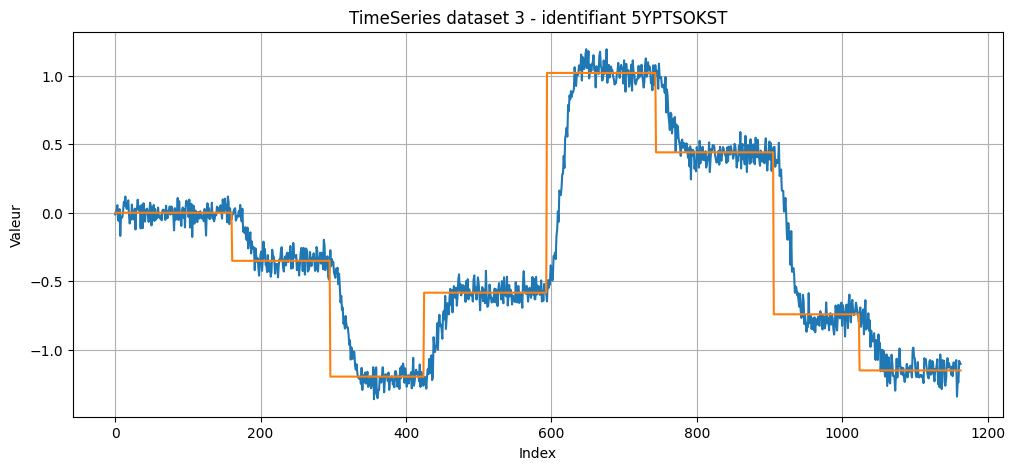

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(df_ts_3.index, df_ts_3["y"], label="Sortie y")
plt.plot(df_ts_3.index, df_ts_3["u"], label="Entrée u")

plt.xlabel("Index")
plt.ylabel("Valeur")
plt.title(f"TimeSeries dataset 3 - identifiant {identifiant_3}")
plt.grid(True)
plt.show()

In [8]:
from pathlib import Path
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd()

# Si on est dans ST4/dataset3, le projet est le dossier parent ST4
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name in ["dataset0", "dataset1", "dataset2", "dataset3"] else CURRENT_DIR

DATASET0_DIR = PROJECT_DIR / "dataset0"
DATASET3_DIR = PROJECT_DIR / "dataset3"

print("CURRENT_DIR  =", CURRENT_DIR)
print("PROJECT_DIR  =", PROJECT_DIR)
print("DATASET0_DIR =", DATASET0_DIR)
print("DATASET3_DIR =", DATASET3_DIR)

# Chargement du modèle normal appris sur dataset0
model_path = DATASET0_DIR / "kde_model_dataset0.pkl"

with open(model_path, "rb") as f:
    model_artifacts = pickle.load(f)

feature_columns = model_artifacts["feature_columns"]
feature_medians = model_artifacts["feature_medians"]
scaler = model_artifacts["scaler"]
pca = model_artifacts["pca"]
kde = model_artifacts["kde"]
threshold = model_artifacts["threshold"]
alpha = model_artifacts.get("alpha", None)
bandwidth = model_artifacts.get("bandwidth", None)
X_kde_sample = model_artifacts.get("X_kde_sample", None)

# Seuil identifiant appris sur dataset0 :
# un identifiant est normal si son % de fenêtres KDE anormales est <= ce seuil.
seuil_id_normal_dataset0 = model_artifacts["seuil_id_normal_dataset0"]
id_threshold_quantile = model_artifacts.get("id_threshold_quantile", 0.97)

print("Modèle dataset0 chargé")
print("Nombre de features attendues :", len(feature_columns))
print("Seuil KDE fenêtre :", threshold)
print("Alpha :", alpha)
print("Bandwidth :", bandwidth)
print("Quantile seuil identifiant :", id_threshold_quantile)
print("Seuil identifiant normal dataset0 :", seuil_id_normal_dataset0, "%")


CURRENT_DIR  = c:\Users\user\Documents\ST4\dataset3
PROJECT_DIR  = c:\Users\user\Documents\ST4
DATASET0_DIR = c:\Users\user\Documents\ST4\dataset0
DATASET3_DIR = c:\Users\user\Documents\ST4\dataset3
Modèle dataset0 chargé
Nombre de features attendues : 246
Seuil KDE fenêtre : -14.004802100248469
Alpha : 0.05
Bandwidth : 2.5
Quantile seuil identifiant : 0.97
Seuil identifiant normal dataset0 : 7.521618903971845 %


In [9]:
# Même cleaning que dataset0/dataset1, mais avec les colonnes apprises sur dataset0

df_dataset3 = features_3.copy()

X_dataset3 = df_dataset3.drop(columns=["i"], errors="ignore")
X_dataset3 = X_dataset3.apply(pd.to_numeric, errors="coerce")
X_dataset3 = X_dataset3.replace([np.inf, -np.inf], np.nan)

# Très important : on force exactement les mêmes colonnes que dataset0
X_dataset3 = X_dataset3.reindex(columns=feature_columns)

# Très important : on remplit avec les médianes apprises sur dataset0
X_dataset3 = X_dataset3.fillna(feature_medians)

print("Shape dataset3 après alignement :", X_dataset3.shape)
print("Nombre de NaN restants :", X_dataset3.isna().sum().sum())
print("Nombre de valeurs infinies :", np.isinf(X_dataset3.to_numpy()).sum())

Shape dataset3 après alignement : (39533, 246)
Nombre de NaN restants : 0
Nombre de valeurs infinies : 0


In [10]:
X_dataset3_scaled = scaler.transform(X_dataset3)

finite_values = X_dataset3_scaled[np.isfinite(X_dataset3_scaled)]

max_finite = np.max(finite_values)
min_finite = np.min(finite_values)

X_dataset3_scaled = np.nan_to_num(
    X_dataset3_scaled,
    nan=0.0,
    posinf=max_finite,
    neginf=min_finite
)

X_dataset3_pca = pca.transform(X_dataset3_scaled)

print("Projection PCA dataset3 terminée")
print("Shape PCA dataset3 :", X_dataset3_pca.shape)

Projection PCA dataset3 terminée
Shape PCA dataset3 : (39533, 2)


In [11]:
# Score KDE avec le modèle normal dataset0

kde_score_dataset3 = kde.score_samples(X_dataset3_pca)

# Une fenêtre est anormale si son score KDE est inférieur au seuil appris sur dataset0
outlier_dataset3 = kde_score_dataset3 < threshold

df_dataset3_result = df_dataset3.copy()

df_dataset3_result["PCA1"] = X_dataset3_pca[:, 0]
df_dataset3_result["PCA2"] = X_dataset3_pca[:, 1]
df_dataset3_result["kde_score"] = kde_score_dataset3
df_dataset3_result["outlier"] = outlier_dataset3
df_dataset3_result["is_normal_window"] = ~outlier_dataset3

print("Nombre total de fenêtres dataset3 :", len(df_dataset3_result))
print("Fenêtres détectées anormales :", df_dataset3_result["outlier"].sum())
print("Pourcentage fenêtres anormales :", round(100 * df_dataset3_result["outlier"].mean(), 2), "%")

Nombre total de fenêtres dataset3 : 39533
Fenêtres détectées anormales : 2536
Pourcentage fenêtres anormales : 6.41 %


In [12]:
# Résumé par identifiant dataset3
# Ici, la décision normal/défaut général utilise seulement le % de fenêtres KDE anormales.

summary_dataset3 = (
    df_dataset3_result
    .groupby("i")
    .agg(
        nb_windows=("outlier", "size"),
        nb_windows_anormales=("outlier", "sum"),
        pct_windows_anormales=("outlier", lambda x: 100 * x.mean()),
        kde_score_mean=("kde_score", "mean"),
        kde_score_min=("kde_score", "min"),
    )
    .reset_index()
)

summary_dataset3["id_normal_dataset0"] = (
    summary_dataset3["pct_windows_anormales"] <= seuil_id_normal_dataset0
)

summary_dataset3["classe_predite_dataset0"] = np.where(
    summary_dataset3["id_normal_dataset0"],
    "normal",
    "defaut"
)

nb_total = len(summary_dataset3)
nb_normaux = summary_dataset3["id_normal_dataset0"].sum()
nb_defauts = nb_total - nb_normaux

print("Résultat dataset3 avec le modèle normal dataset0 :")
print("Seuil accepté pour un identifiant normal :", seuil_id_normal_dataset0, "%")
print("Identifiants normaux :", nb_normaux)
print("Identifiants défauts :", nb_defauts)
print("Total :", nb_total)
print("Pourcentage normaux :", round(100 * nb_normaux / nb_total, 2), "%")
print("Pourcentage défauts :", round(100 * nb_defauts / nb_total, 2), "%")

display(
    summary_dataset3
    .sort_values("pct_windows_anormales", ascending=False)
)

Résultat dataset3 avec le modèle normal dataset0 :
Seuil accepté pour un identifiant normal : 7.521618903971845 %
Identifiants normaux : 102
Identifiants défauts : 58
Total : 160
Pourcentage normaux : 63.75 %
Pourcentage défauts : 36.25 %


,i,nb_windows,nb_windows_anormales,pct_windows_anormales,kde_score_mean,kde_score_min,id_normal_dataset0,classe_predite_dataset0
24,5KFR98ZLG,284,51,17.957746,-17.656281,-1695.940388,False,defaut
27,5U9NEKIVD,252,35,13.888889,-7.317254,-52.544919,False,defaut
143,VNQC0I68P,265,36,13.584906,-11.118638,-505.026057,False,defaut
73,FF1L7K1AM,346,47,13.583815,-9.408130,-212.115436,False,defaut
57,BOYA1T5ZU,173,22,12.716763,-9.622030,-226.714282,False,defaut
...,...,...,...,...,...,...,...,...
89,IGHHR5SXT,252,3,1.190476,-5.293392,-16.875491,True,normal
156,ZDLLEXOUQ,174,2,1.149425,-5.175874,-27.718313,True,normal
40,7ZBM38YV2,189,2,1.058201,-5.996674,-15.333934,True,normal
28,5W74YJMXB,193,2,1.036269,-5.622256,-20.946081,True,normal


In [13]:
result_path = DATASET3_DIR / "summary_detection_dataset3.pkl"
window_result_path = DATASET3_DIR / "windows_detection_dataset3.pkl"

summary_dataset3.to_pickle(result_path)
df_dataset3_result.to_pickle(window_result_path)

print("Résumé par identifiant sauvegardé dans :", result_path)
print("Résultat fenêtre par fenêtre sauvegardé dans :", window_result_path)

Résumé par identifiant sauvegardé dans : c:\Users\user\Documents\ST4\dataset3\summary_detection_dataset3.pkl
Résultat fenêtre par fenêtre sauvegardé dans : c:\Users\user\Documents\ST4\dataset3\windows_detection_dataset3.pkl
